In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Iris Dataset**

# Classification using ANN from Scratch

### Load and preprocess

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()
X = pd.DataFrame(data=iris.data,  
                  columns=iris.feature_names) 
y=iris.target.reshape(-1,1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

### define activation functions

In [6]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
    return x*(1-x)
def relu(x):
    return np.maximum(0,x)
def relu_derivative(x):
    return np.where(x>0,1,0)

### Define class Neural Network

In [7]:
class NeuralNetwork:
    
    # Initialize weights and biases
    def __init__(self,input_size,hidden_size,output_size):
        # Intialize weights
        self.weights_input_hidden=np.random.randn(input_size,hidden_size)
        self.weights_hidden_output=np.random.randn(hidden_size,output_size)
        # Initialize biases
        self.bias_hidden=np.zeros((1,hidden_size))
        self.bias_output=np.zeros((1,output_size))

    # Forward propagation
    def forward_prop(self,X):
        self.hidden_layer_input=np.dot(X,self.weights_input_hidden)+self.bias_hidden
        self.hidden_layer_output=relu(self.hidden_layer_input)
        self.output_layer_input=np.dot(self.hidden_layer_output,self.weights_hidden_output)+self.bias_output
        self.output=sigmoid(self.output_layer_input)
        return self.output

    # Backward propagation
    def backward_prop(self,X,y,learning_rate):
        # calculate error
        output_error=y-self.output
        output_delta=output_error*sigmoid_derivative(self.output)
        hidden_error=output_delta.dot(self.weights_hidden_output.T)
        hidden_delta=hidden_error*relu_derivative(self.hidden_layer_output)
        # update weights and biases
        self.weights_hidden_output+=self.hidden_layer_output.T.dot(output_delta)*learning_rate
        self.bias_output+=np.sum(output_delta,axis=0,keepdims=True)*learning_rate
        self.weights_input_hidden+=X.T.dot(hidden_delta)*learning_rate
        self.bias_hidden+=np.sum(hidden_delta,axis=0,keepdims=True)*learning_rate

    # Train the model
    def train(self,X,y,epochs,learning_rate):
        for epoch in range(epochs):
            self.forward_prop(X)
            self.backward_prop(X,y,learning_rate)
            if epoch%1000==0:
                loss=np.mean(np.square(y-self.output))
                print(f'Epoch:{epoch}-->Loss:{loss}')

### Create the Neural Network

In [8]:
nn=NeuralNetwork(input_size=4,hidden_size=5,output_size=3)
nn.train(X_train,y_train,epochs=10000,learning_rate=0.01)

Epoch:0-->Loss:1.345705179000535
Epoch:1000-->Loss:0.352568218584981
Epoch:2000-->Loss:0.3524213836565976
Epoch:3000-->Loss:0.3524040910323123
Epoch:4000-->Loss:0.3523970037751142
Epoch:5000-->Loss:0.3523931708127475
Epoch:6000-->Loss:0.35239077922643774
Epoch:7000-->Loss:0.3523891495223159
Epoch:8000-->Loss:0.3523879702414941
Epoch:9000-->Loss:0.3523870787937842


### Make predictions and test accuracy

In [9]:
# Test the Neural Network
predictions = nn.forward_prop(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = np.mean(predicted_classes == true_classes)
print(f'Accuracy: {accuracy * 100}%')

Accuracy: 31.11111111111111%


# Classification using ANN (TensorFlow,Keras)

### Load data and preprocess

In [22]:
df=pd.read_csv('/kaggle/input/customer1/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [24]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [39]:
X=df.drop('Exited',axis=1)
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

### Build the model

In [43]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [62]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=11)) # -> hidden layer 1
model.add(Dense(32,activation='relu')) # --. hidden layer 2
model.add(Dense(1,activation='sigmoid')) # --> output layer

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(X_train,y_train,epochs=10)

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8870 - loss: 0.2657
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8884 - loss: 0.2631
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8850 - loss: 0.2668
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8910 - loss: 0.2587
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8848 - loss: 0.2681
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8864 - loss: 0.2620
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8911 - loss: 0.2561
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8894 - loss: 0.2575
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8892 - loss: 0.2551
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8853 - loss: 0.2644


In [77]:
y_pred=np.where(model.predict(X_test)>0.5,1,0)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [78]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8496969696969697


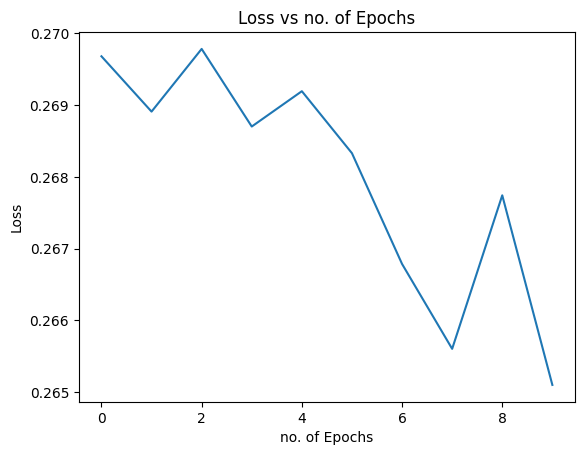

In [79]:
import matplotlib.pyplot as plt
plt.title('Loss vs no. of Epochs')
plt.xlabel('no. of Epochs')
plt.ylabel('Loss')
plt.plot(history.history['loss'])
plt.show()

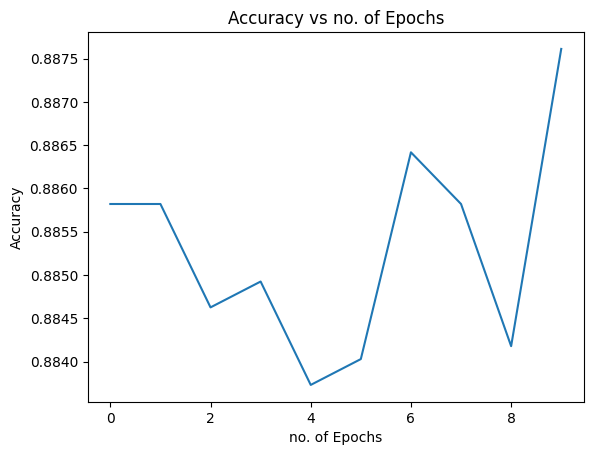

In [80]:
plt.title('Accuracy vs no. of Epochs')
plt.xlabel('no. of Epochs')
plt.ylabel('Accuracy')
plt.plot(history.history['accuracy'])
plt.show()